In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = Path("../data/processed")
SPLITS    = ["train", "val", "test"]
LABELS    = ["open", "closed"]
EXTS      = {".jpg", ".jpeg", ".png"}

# Count images
rows = []
for split in SPLITS:
    for label in LABELS:
        d = PROCESSED / split / label
        n = len([f for f in d.iterdir()
                  if f.suffix.lower() in EXTS]) if d.exists() else 0
        rows.append({"split": split, "label": label, "count": n})

df = pd.DataFrame(rows)
print(df.pivot(index="split", columns="label", values="count"))

# Compute imbalance ratio for training set
tr = df[df["split"] == "train"]
n_open   = tr[tr["label"]=="open"]["count"].values[0]
n_closed = tr[tr["label"]=="closed"]["count"].values[0]
ratio    = n_open / n_closed if n_closed > 0 else 0

print(f"\nImbalance ratio (open:closed) = {ratio:.2f}:1")
if   ratio < 1.5: print("Status: GOOD — balanced enough, use equal class weights")
elif ratio < 2.5: print("Status: MILD — use weighted loss (closed weight ~2.0)")
else:             print("Status: SEVERE — use weighted loss AND consider undersampling")

label  closed   open
split               
test    10626  10536
train   43045  41326
val     10623  10535

Imbalance ratio (open:closed) = 0.96:1
Status: GOOD — balanced enough, use equal class weights


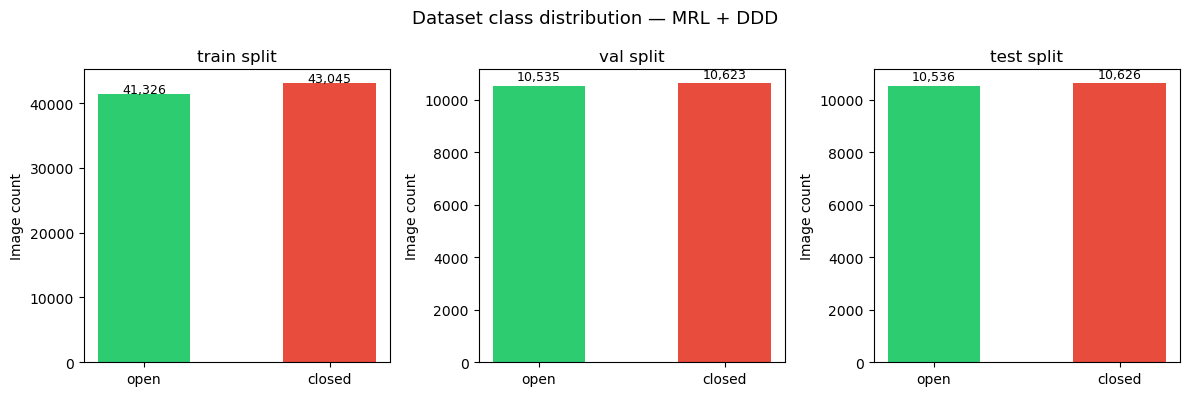

Saved → outputs/class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, split in zip(axes, SPLITS):
    sub = df[df["split"] == split]
    colors = ["#2ecc71", "#e74c3c"]
    bars = ax.bar(sub["label"], sub["count"], color=colors, width=0.5)
    ax.set_title(f"{split} split", fontsize=12)
    ax.set_ylabel("Image count")
    for bar, row in zip(bars, sub.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"{row.count:,}", ha="center", fontsize=9)

plt.suptitle("Dataset class distribution — MRL + DDD", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/class_distribution.png")